# Comparing dataset with CosmoPower

In [21]:
import os
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import cosmopower

In [2]:
MAX_SAMPLES = 100
NUM_ELL = 2999

train_cosmologies = np.loadtxt("../data/train/cosmologies.txt")
data = np.zeros((MAX_SAMPLES, 3, NUM_ELL))
for i in range(1, MAX_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/train/cl_{i}.txt", unpack=True)
    data[i-1, 0] = cl_tt
    data[i-1, 1] = cl_te
    data[i-1, 2] = cl_ee

In [4]:
# load pre-trained NN model: maps cosmological parameters to CMB TT log-C_ell
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
cp_nn_tt = cosmopower.cosmopower_NN(restore=True,
                                    restore_filename="/Users/joao/cosmo/cosmopower/cosmopower/trained_models/CP_paper/CMB/cmb_TT_NN")

2026-08-11 09:47:41.911068: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-08-11 09:47:41.911098: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-08-11 09:47:41.911101: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-08-11 09:47:41.911310: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-11 09:47:41.911443: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Text(0.5, 1.0, 'Comparison between CosmoPower and training set')

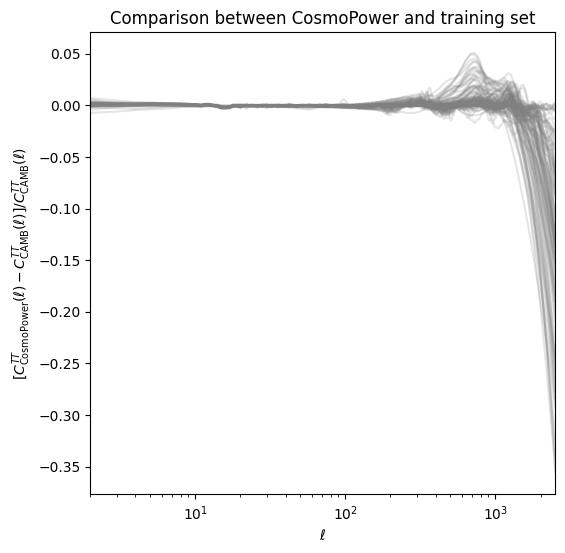

In [15]:
fig = plt.figure(figsize=(6, 6))

ell = np.arange(2, 3001)
for i in range(MAX_SAMPLES):
    h, omch2, ombh2, ln1010As, ns, tau = train_cosmologies[i]
    params = {"h": [h], "omega_cdm": [omch2], "omega_b": [ombh2], "ln10^{10}A_s": [ln1010As], "n_s": [ns], "tau_reio": [tau], }

    cl_tt_cosmopower = cp_nn_tt.ten_to_predictions_np(params)[0]
    ell_cosmopower = ell[:len(cl_tt_cosmopower)]
    cl_tt_cosmopower *= ell_cosmopower*(ell_cosmopower+1)/(2*np.pi)
    cl_tt, cl_te, cl_ee = data[i]
    units_factor = (2.7255*1e6)**2
    cl_tt = cl_tt[:len(cl_tt_cosmopower)]/units_factor
    plt.semilogx(ell_cosmopower, (cl_tt_cosmopower - cl_tt)/cl_tt, color="gray", alpha=0.2)
plt.xlabel("$\\ell$")
plt.ylabel("$[C_\\mathrm{CosmoPower}^{TT}(\\ell) - C_\\mathrm{CAMB}^{TT}(\\ell)] / C_\\mathrm{CAMB}^{TT}(\\ell)$")
plt.xlim([ell_cosmopower[0], ell_cosmopower[-1]])
plt.title("Comparison between CosmoPower and training set")

In [24]:
num_evals = 50
start = perf_counter()
for _ in range(num_evals):
    cl_tt_cosmopower = cp_nn_tt.ten_to_predictions_np(params)[0]
end = perf_counter()
print(f"Took {(end - start)/num_evals:.3f} seconds on average ({num_evals} evals)")

Took 0.002 seconds on average (50 evals)
